In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare

In [2]:
def outcome(pred_base, pred_weighted, label, mode="2class"):
    """
    Compare baseline and weighted model predictions using a given evaluation mode.
    mode: one of {"regression", "7class", "5class", "2class", "2class_non0"}
    """

    if mode == "7class":
        base_correct = int(np.clip(pred_base, -3, 3)) == int(np.clip(label, -3, 3))
        weighted_correct = int(np.clip(pred_weighted, -3, 3)) == int(np.clip(label, -3, 3))

    elif mode == "5class":
        base_correct = int(np.clip(pred_base, -2, 2)) == int(np.clip(label, -2, 2))
        weighted_correct = int(np.clip(pred_weighted, -2, 2)) == int(np.clip(label, -2, 2))

    elif mode == "2class":
        base_correct = (pred_base >= 0) == (label >= 0)
        weighted_correct = (pred_weighted >= 0) == (label >= 0)

    elif mode == "2class_non0":
        if label == 0:
            return "ignore"
        base_correct = (pred_base > 0) == (label > 0)
        weighted_correct = (pred_weighted > 0) == (label > 0)

    else:
        raise ValueError("Unknown mode")

    if not base_correct and weighted_correct:
        return "corrected"
    elif base_correct and not weighted_correct:
        return "regressed"
    elif base_correct and weighted_correct:
        return "both_correct"
    else:
        return "both_wrong"


In [3]:
import ast

def to_float(x):
    if isinstance(x, float) or isinstance(x, int):
        return float(x)
    elif isinstance(x, list):
        return float(x[0])
    elif isinstance(x, str) and x.startswith("["):
        try:
            return float(ast.literal_eval(x)[0])
        except:
            return float('nan')
    else:
        return float(x)

In [4]:
def run_outcome_analysis(root_path, paths, dataset, model_base='baseline', model_weighted='KL'):
    # Load CSVs
    runs = {}
    for run_name, path in paths.items():
        df_train = pd.read_csv(f'{root_path}/{path}/{dataset}_text_audio_video_1_train_results.csv')
        df_dev   = pd.read_csv(f'{root_path}/{path}/{dataset}_text_audio_video_1_dev_results.csv')
        df_test  = pd.read_csv(f'{root_path}/{path}/{dataset}_text_audio_video_1_test_results.csv')

        #df_train["split"] = "train"
        #df_dev["split"]   = "dev"
        df_test["split"]  = "test"

        runs[run_name] = pd.concat([df_test], ignore_index=True)

    # Merge base and weighted runs
    merged = runs[model_base].merge(runs[model_weighted], on='ids', suffixes=(f'_{model_base}', f'_{model_weighted}'))

    # Keep a consistent GT and split column
    merged['Ground_Truth'] = merged[f'Ground_Truth_{model_base}']
    assert (merged[f'split_{model_base}'] == merged[f'split_{model_weighted}']).all()
    merged['split'] = merged[f'split_{model_base}']

    # Convert to float
    for col in [f'Predicted_{model_base}', f'Predicted_{model_weighted}', 'Ground_Truth']:
        merged[col] = merged[col].apply(to_float)

    # Classification-style outcome labeling
    modes = ["7class", "5class", "2class", "2class_non0"]
    for mode in modes:
        merged[f'outcome_{mode}'] = merged.apply(
            lambda r: outcome(r[f'Predicted_{model_base}'], r[f'Predicted_{model_weighted}'], r['Ground_Truth'], mode),
            axis=1
        )

    # Regression error analysis
    regression_df = merged[["ids", "split", f'Predicted_{model_base}', f'Predicted_{model_weighted}', "Ground_Truth"]].copy()
    regression_df["err_baseline"] = abs(regression_df[f'Predicted_{model_base}'] - regression_df["Ground_Truth"])
    regression_df["err_weighted"] = abs(regression_df[f'Predicted_{model_weighted}'] - regression_df["Ground_Truth"])
    regression_df["delta_err"] = regression_df["err_baseline"] - regression_df["err_weighted"]

    # Print summary for classification modes
    summary = {}
    for mode in modes:
        counts = merged[f'outcome_{mode}'].value_counts()
        summary[mode] = {
            'corrected': counts.get('corrected', 0),
            'regressed': counts.get('regressed', 0),
            'both_correct': counts.get('both_correct', 0),
            'both_wrong': counts.get('both_wrong', 0),
            'net_gain': counts.get('corrected', 0) - counts.get('regressed', 0)
        }

    print(pd.DataFrame(summary).T)
    print("\nRegression ΔError (baseline - weighted):")
    print(regression_df["delta_err"].describe())

    return merged, regression_df


In [5]:
def get_regression_outcome(delta):
    if delta > 0:
        return "corrected"
    elif delta < 0:
        return "regressed"
    else:
        return "unchanged"

# Joint KL

In [6]:
root_path = "/data/wang/junh/results/MMIM/"
paths = {
    "baseline":  "final/noWeights",
    "KL":        "final/kl_joint",
    "KL+CC":     "final/kl_joint_cc",
    "KL+MI":     "final/kl_joint_mi",
}

In [7]:
dataset = "mosi"
merged_mosi_kl, regression_mosi_kl = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL")

             corrected  regressed  both_correct  both_wrong  net_gain
7class              85        110           237         254       -25
5class              85        113           240         248       -28
2class              41         34           521          90         7
2class_non0         34         34           517          71         0

Regression ΔError (baseline - weighted):
count    686.000000
mean      -0.012939
std        0.576163
min       -3.153849
25%       -0.317099
50%       -0.010374
75%        0.246931
max        2.554574
Name: delta_err, dtype: float64


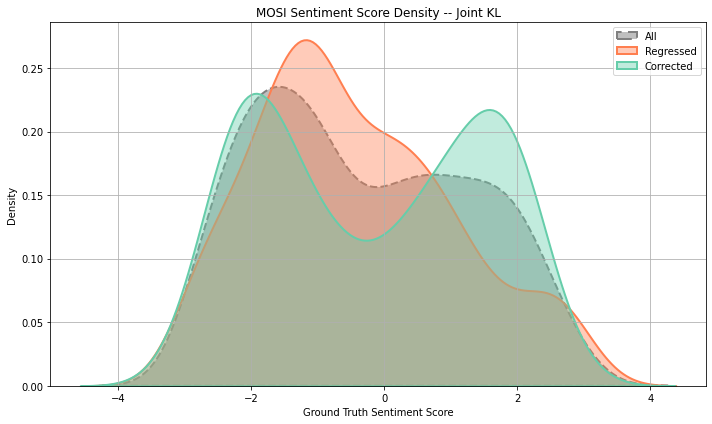

In [8]:
regression_mosi_kl["regression_outcome"] = regression_mosi_kl["delta_err"].apply(get_regression_outcome)

# Subsets
all_data = regression_mosi_kl
fixed = all_data[all_data["regression_outcome"] == "corrected"]
regressed = all_data[all_data["regression_outcome"] == "regressed"]

# Plot KDE
plt.figure(figsize=(10, 6))
sns.kdeplot(all_data["Ground_Truth"], fill=True, label="All", linestyle="--", alpha=0.5, linewidth=2, color='gray')
sns.kdeplot(regressed["Ground_Truth"], fill=True, label="Regressed", alpha=0.4, linewidth=2, color='coral')
sns.kdeplot(fixed["Ground_Truth"], fill=True, label="Corrected", alpha=0.4, linewidth=2, color='mediumaquamarine')

plt.xlabel("Ground Truth Sentiment Score")
plt.ylabel("Density")
plt.title("MOSI Sentiment Score Density -- Joint KL")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

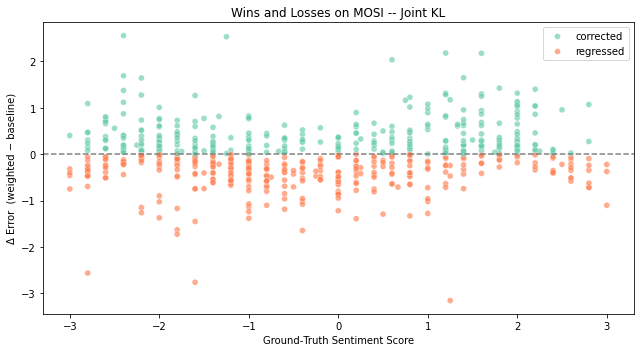

In [9]:
all_data["regression_outcome"] = np.where(
    all_data["delta_err"] > 0, "corrected",
    np.where(all_data["delta_err"] < 0, "regressed", "unchanged")
)

# keep only points that actually changed
changed = all_data.query("regression_outcome != 'unchanged'")

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=changed,
    x="Ground_Truth",
    y="delta_err",
    hue="regression_outcome",
    palette={"corrected": "mediumaquamarine", "regressed": "coral"},
    alpha=0.65
)

plt.axhline(0, color="gray", ls="--")
plt.xlabel("Ground‑Truth Sentiment Score")
plt.ylabel("Δ Error  (weighted − baseline)")
plt.title("Wins and Losses on MOSI -- Joint KL")
plt.legend(title="")
plt.tight_layout()
plt.show()

In [10]:
dataset = "mosei"
merged_mosei_kl, regression_mosei_kl = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL")

             corrected  regressed  both_correct  both_wrong  net_gain
7class             476        456          2467        1260        20
5class             498        456          2467        1238        42
2class             580        256          3267         556       324
2class_non0        308        236          2754         336        72

Regression ΔError (baseline - weighted):
count    4659.000000
mean        0.000887
std         0.433751
min        -3.392145
25%        -0.179268
50%         0.008857
75%         0.210505
max         3.272220
Name: delta_err, dtype: float64


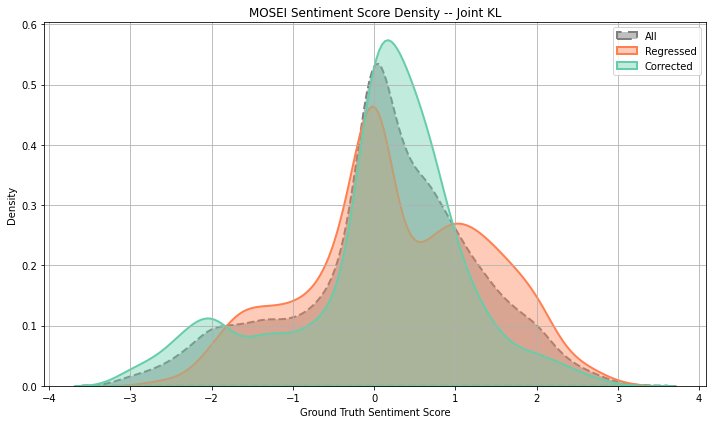

In [11]:
regression_mosei_kl["regression_outcome"] = regression_mosei_kl["delta_err"].apply(get_regression_outcome)

# Subsets
all_data = regression_mosei_kl
fixed = all_data[all_data["regression_outcome"] == "corrected"]
regressed = all_data[all_data["regression_outcome"] == "regressed"]

# Plot KDE
plt.figure(figsize=(10, 6))
sns.kdeplot(all_data["Ground_Truth"], fill=True, label="All", linestyle="--", alpha=0.5, linewidth=2, color='gray')
sns.kdeplot(regressed["Ground_Truth"], fill=True, label="Regressed", alpha=0.4, linewidth=2, color='coral')
sns.kdeplot(fixed["Ground_Truth"], fill=True, label="Corrected", alpha=0.4, linewidth=2, color='mediumaquamarine')

plt.xlabel("Ground Truth Sentiment Score")
plt.ylabel("Density")
plt.title("MOSEI Sentiment Score Density -- Joint KL")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

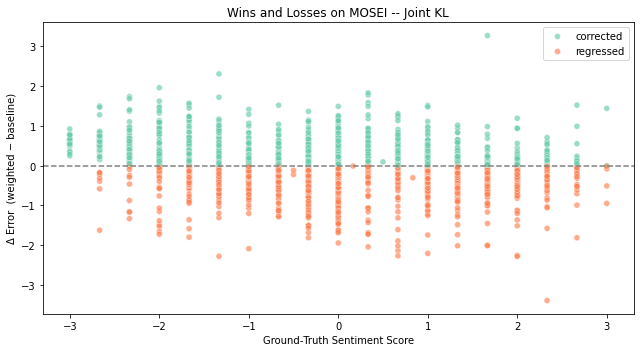

In [12]:
all_data["regression_outcome"] = np.where(
    all_data["delta_err"] > 0, "corrected",
    np.where(all_data["delta_err"] < 0, "regressed", "unchanged")
)

# keep only points that actually changed
changed = all_data.query("regression_outcome != 'unchanged'")

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=changed,
    x="Ground_Truth",
    y="delta_err",
    hue="regression_outcome",
    palette={"corrected": "mediumaquamarine", "regressed": "coral"},
    alpha=0.65
)

plt.axhline(0, color="gray", ls="--")
plt.xlabel("Ground‑Truth Sentiment Score")
plt.ylabel("Δ Error  (weighted − baseline)")
plt.title("Wins and Losses on MOSEI -- Joint KL")
plt.legend(title="")
plt.tight_layout()
plt.show()

# Joint KL + CC

In [13]:
dataset = "mosi"
merged_mosi_kl_cc, regression_mosi_kl_cc = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL+CC")

             corrected  regressed  both_correct  both_wrong  net_gain
7class             100         87           260         239        13
5class             100         88           265         233        12
2class              22         20           535         109         2
2class_non0         21         19           532          84         2

Regression ΔError (baseline - weighted):
count    686.000000
mean       0.004803
std        0.477744
min       -2.911192
25%       -0.234982
50%       -0.001860
75%        0.220460
max        3.094535
Name: delta_err, dtype: float64


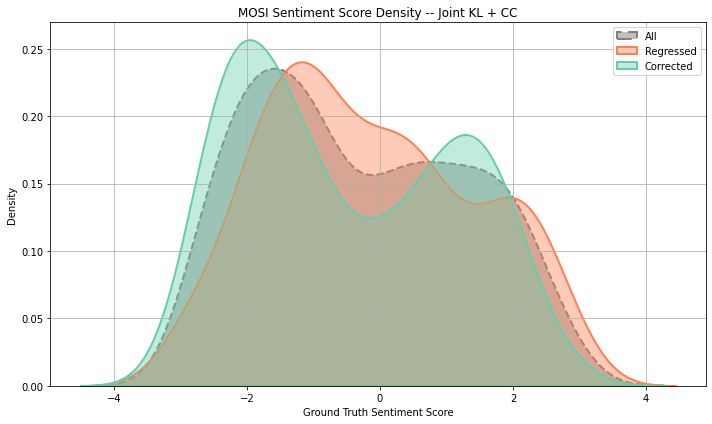

In [14]:
regression_mosi_kl_cc["regression_outcome"] = regression_mosi_kl_cc["delta_err"].apply(get_regression_outcome)

# Subsets
all_data = regression_mosi_kl_cc
fixed = all_data[all_data["regression_outcome"] == "corrected"]
regressed = all_data[all_data["regression_outcome"] == "regressed"]

# Plot KDE
plt.figure(figsize=(10, 6))
sns.kdeplot(all_data["Ground_Truth"], fill=True, label="All", linestyle="--", alpha=0.5, linewidth=2, color='gray')
sns.kdeplot(regressed["Ground_Truth"], fill=True, label="Regressed", alpha=0.4, linewidth=2, color='coral')
sns.kdeplot(fixed["Ground_Truth"], fill=True, label="Corrected", alpha=0.4, linewidth=2, color='mediumaquamarine')

plt.xlabel("Ground Truth Sentiment Score")
plt.ylabel("Density")
plt.title("MOSI Sentiment Score Density -- Joint KL + CC")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

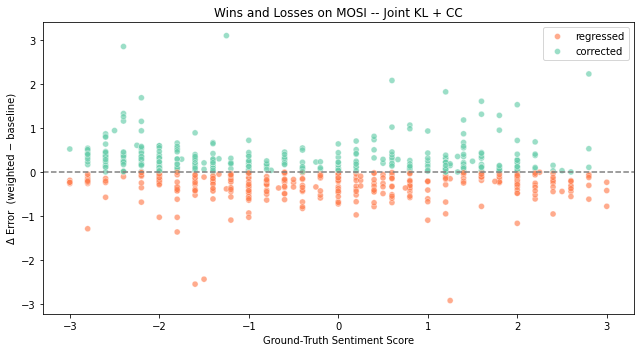

In [15]:
all_data["regression_outcome"] = np.where(
    all_data["delta_err"] > 0, "corrected",
    np.where(all_data["delta_err"] < 0, "regressed", "unchanged")
)

# keep only points that actually changed
changed = all_data.query("regression_outcome != 'unchanged'")

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=changed,
    x="Ground_Truth",
    y="delta_err",
    hue="regression_outcome",
    palette={"corrected": "mediumaquamarine", "regressed": "coral"},
    alpha=0.65
)

plt.axhline(0, color="gray", ls="--")
plt.xlabel("Ground‑Truth Sentiment Score")
plt.ylabel("Δ Error  (weighted − baseline)")
plt.title("Wins and Losses on MOSI -- Joint KL + CC")
plt.legend(title="")
plt.tight_layout()
plt.show()

In [16]:
dataset = "mosei"
merged_mosei_kl_cc, regression_mosei_kl_cc  = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL+CC")

             corrected  regressed  both_correct  both_wrong  net_gain
7class             316        304          2619        1420        12
5class             316        304          2619        1420        12
2class             709        341          3182         427       368
2class_non0        345        330          2660         299        15

Regression ΔError (baseline - weighted):
count    4659.000000
mean        0.005760
std         0.374789
min        -3.039130
25%        -0.184329
50%        -0.005195
75%         0.212238
max         2.639181
Name: delta_err, dtype: float64


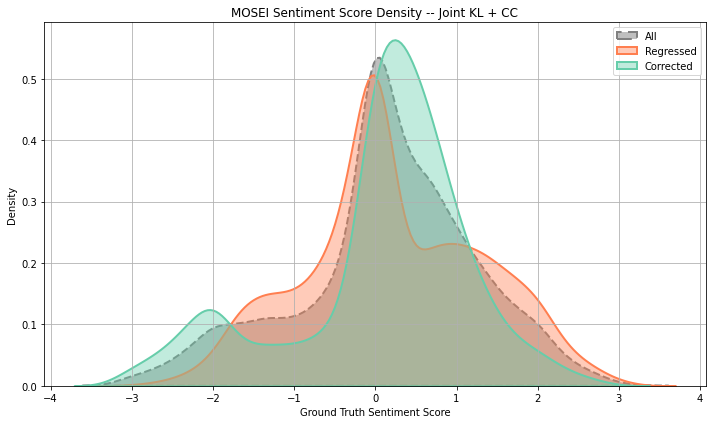

In [25]:
regression_mosei_kl_cc["regression_outcome"] = regression_mosei_kl_cc["delta_err"].apply(get_regression_outcome)

# Subsets
all_data = regression_mosei_kl_cc
fixed = all_data[all_data["regression_outcome"] == "corrected"]
regressed = all_data[all_data["regression_outcome"] == "regressed"]

# Plot KDE
plt.figure(figsize=(10, 6))
sns.kdeplot(all_data["Ground_Truth"], fill=True, label="All", linestyle="--", alpha=0.5, linewidth=2, color='gray')
sns.kdeplot(regressed["Ground_Truth"], fill=True, label="Regressed", alpha=0.4, linewidth=2, color='coral')
sns.kdeplot(fixed["Ground_Truth"], fill=True, label="Corrected", alpha=0.4, linewidth=2, color='mediumaquamarine')

plt.xlabel("Ground Truth Sentiment Score")
plt.ylabel("Density")
plt.title("MOSEI Sentiment Score Density -- Joint KL + CC")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

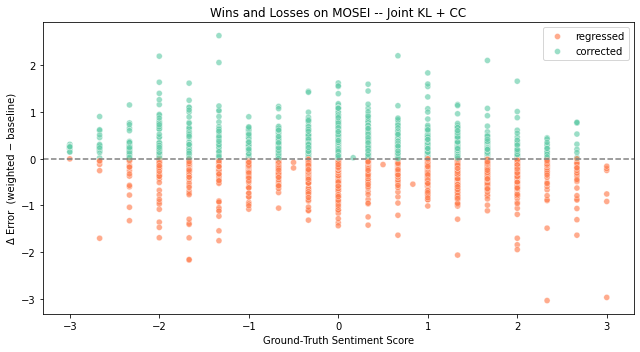

In [18]:
all_data["regression_outcome"] = np.where(
    all_data["delta_err"] > 0, "corrected",
    np.where(all_data["delta_err"] < 0, "regressed", "unchanged")
)

# keep only points that actually changed
changed = all_data.query("regression_outcome != 'unchanged'")

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=changed,
    x="Ground_Truth",
    y="delta_err",
    hue="regression_outcome",
    palette={"corrected": "mediumaquamarine", "regressed": "coral"},
    alpha=0.65
)

plt.axhline(0, color="gray", ls="--")
plt.xlabel("Ground‑Truth Sentiment Score")
plt.ylabel("Δ Error  (weighted − baseline)")
plt.title("Wins and Losses on MOSEI -- Joint KL + CC")
plt.legend(title="")
plt.tight_layout()
plt.show()

# Joint KL + MI

In [19]:
dataset = "mosi"
merged_mosi_kl_mi, regression_mosi_kl_mi  = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL+MI")

             corrected  regressed  both_correct  both_wrong  net_gain
7class              43         69           278         296       -26
5class              43         69           284         290       -26
2class              38         28           527          93        10
2class_non0         30         27           524          75         3

Regression ΔError (baseline - weighted):
count    686.000000
mean       0.000268
std        0.471077
min       -4.139061
25%       -0.204374
50%       -0.006341
75%        0.202555
max        3.381807
Name: delta_err, dtype: float64


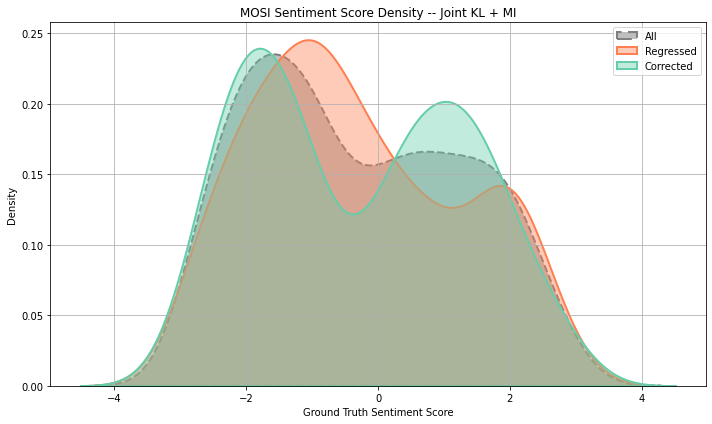

In [20]:
regression_mosi_kl_mi["regression_outcome"] = regression_mosi_kl_mi["delta_err"].apply(get_regression_outcome)

# Subsets
all_data = regression_mosi_kl_mi
fixed = all_data[all_data["regression_outcome"] == "corrected"]
regressed = all_data[all_data["regression_outcome"] == "regressed"]

# Plot KDE
plt.figure(figsize=(10, 6))
sns.kdeplot(all_data["Ground_Truth"], fill=True, label="All", linestyle="--", alpha=0.5, linewidth=2, color='gray')
sns.kdeplot(regressed["Ground_Truth"], fill=True, label="Regressed", alpha=0.4, linewidth=2, color='coral')
sns.kdeplot(fixed["Ground_Truth"], fill=True, label="Corrected", alpha=0.4, linewidth=2, color='mediumaquamarine')

plt.xlabel("Ground Truth Sentiment Score")
plt.ylabel("Density")
plt.title("MOSI Sentiment Score Density -- Joint KL + MI")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

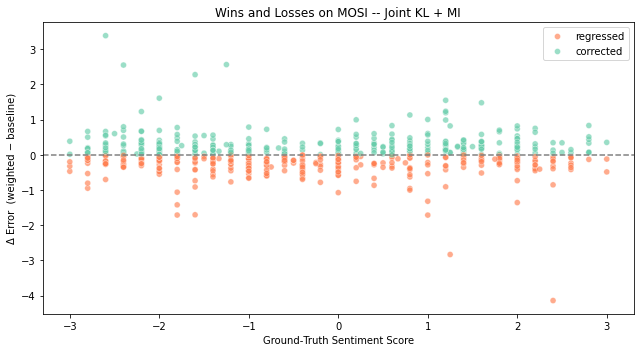

In [21]:
all_data["regression_outcome"] = np.where(
    all_data["delta_err"] > 0, "corrected",
    np.where(all_data["delta_err"] < 0, "regressed", "unchanged")
)

# keep only points that actually changed
changed = all_data.query("regression_outcome != 'unchanged'")

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=changed,
    x="Ground_Truth",
    y="delta_err",
    hue="regression_outcome",
    palette={"corrected": "mediumaquamarine", "regressed": "coral"},
    alpha=0.65
)

plt.axhline(0, color="gray", ls="--")
plt.xlabel("Ground‑Truth Sentiment Score")
plt.ylabel("Δ Error  (weighted − baseline)")
plt.title("Wins and Losses on MOSI -- Joint KL + MI")
plt.legend(title="")
plt.tight_layout()
plt.show()

In [22]:
dataset = "mosei"
merged_mosei_kl_mi, regression_mosei_kl_mi  = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL+MI")

             corrected  regressed  both_correct  both_wrong  net_gain
7class             495        284          2639        1241       211
5class             504        284          2639        1232       220
2class             765        394          3129         371       371
2class_non0        381        387          2603         263        -6

Regression ΔError (baseline - weighted):
count    4659.000000
mean        0.049085
std         0.434198
min        -2.518589
25%        -0.136478
50%         0.030672
75%         0.234306
max         3.295629
Name: delta_err, dtype: float64


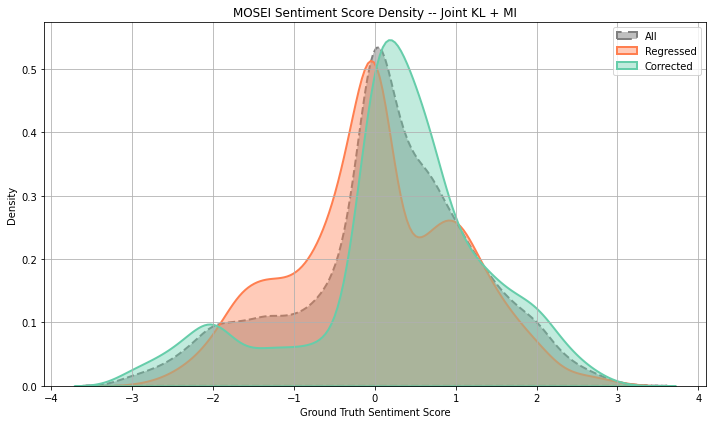

In [23]:
regression_mosei_kl_mi["regression_outcome"] = regression_mosei_kl_mi["delta_err"].apply(get_regression_outcome)

# Subsets
all_data = regression_mosei_kl_mi
fixed = all_data[all_data["regression_outcome"] == "corrected"]
regressed = all_data[all_data["regression_outcome"] == "regressed"]

# Plot KDE
plt.figure(figsize=(10, 6))
sns.kdeplot(all_data["Ground_Truth"], fill=True, label="All", linestyle="--", alpha=0.5, linewidth=2, color='gray')
sns.kdeplot(regressed["Ground_Truth"], fill=True, label="Regressed", alpha=0.4, linewidth=2, color='coral')
sns.kdeplot(fixed["Ground_Truth"], fill=True, label="Corrected", alpha=0.4, linewidth=2, color='mediumaquamarine')

plt.xlabel("Ground Truth Sentiment Score")
plt.ylabel("Density")
plt.title("MOSEI Sentiment Score Density -- Joint KL + MI")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

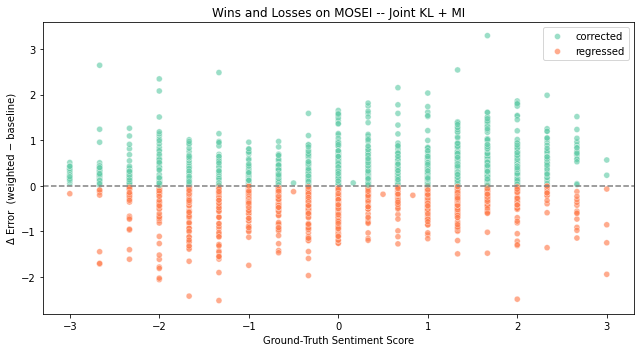

In [24]:
all_data["regression_outcome"] = np.where(
    all_data["delta_err"] > 0, "corrected",
    np.where(all_data["delta_err"] < 0, "regressed", "unchanged")
)

# keep only points that actually changed
changed = all_data.query("regression_outcome != 'unchanged'")

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=changed,
    x="Ground_Truth",
    y="delta_err",
    hue="regression_outcome",
    palette={"corrected": "mediumaquamarine", "regressed": "coral"},
    alpha=0.65
)

plt.axhline(0, color="gray", ls="--")
plt.xlabel("Ground‑Truth Sentiment Score")
plt.ylabel("Δ Error  (weighted − baseline)")
plt.title("Wins and Losses on MOSEI -- Joint KL + MI")
plt.legend(title="")
plt.tight_layout()
plt.show()